# Agentic Document Processing Pipeline Research Notebook

## Phase 1:: Explore processing with just OCR (Tesseract)
### Objectives:
    - parsing and extracting information from the document
    - building an agent equipped with tesseract OCR tool

    * Limitations:
    OCR converts pixels to text. OCR alone produces raw text, but without context, syntax and information coherence.

In [1]:
# Needed Libraries
# Pillow (PIL): Load and manipulate images
# Pytesseract: Python wrapper for Tesseract OCR engine
# LangChain: Framework for building tool-enabled LLM applications
# Langgraph: for building graph-based agents


from PIL import Image
import pytesseract

from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import HumanMessage, SystemMessage, AnyMessage
from langgraph.prebuilt import tools_condition, ToolNode
from pydantic import BaseModel
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import os

from langchain.tools import tool

load_dotenv()


True

# Define tool

In [2]:
path = os.getcwd()
print(path)
path_dir =  os.path.join(os.getcwd(), 'adam')
print(path_dir)

/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/adp
/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/adp/adam


In [3]:
# create the ocr tool
@tool
def read_image_with_ocr(image_file:str) -> str:
    """ read an image using ocr and extract the texts """
    from PIL import Image
    # read current working directory
    image_path = os.path.join(os.getcwd(), image_file)
    try:
        text =  pytesseract.image_to_string(image = Image.open(image_path))
        return text
    except Exception as e:
        return f"error reading image: {e}"

tools = [read_image_with_ocr]

In [4]:
# confirming the function tool works
# provide a path to an image file
data_file = 'IELTS_2025.jpg'
image_text = read_image_with_ocr.run(data_file)
print('raw ocr output:\n\n', image_text)

raw ocr output:

 3
;

IELTS

Test Report Form GENERAL TRAINING

NOTE. Admission to under ;
‘graduate and post graduate courses should-be based on the ACADEMIC Readin iti
x re - g and. Writing Modules.
BAC TRAINING Reading and Writing Modules are not designed to test the full range of language skills required for academic purposes.
is recommended that the candidate's language ability as indicated in this Test Report Form be re-assessed after two years from the date of the test.

Centre Number ~ 34400 Date 08/FEB/2025 | Candidate Number 000248

Candidate Details

First Name , CHIBUIKE EUGENE es p oN
Candidate ID 850118962 ee .

Date of Birth 28/01/1992 Sex (M/F) Scheme Code ~|« Private Candidate
Country or Region
of Origin

Country of
Nationality NIGERIA
First Language ENGLISH

Test Results

CT |
Overall

Writing 7.5 | Speaking 8.5 Band
Score

CEFR

Listening k Reading Level

Administrator Comments tre stamp Validation stamp
Seth OEP |

<
= Y.

Administrator's

Signature CoC ORC

Test R

# Define the LLM 

In [5]:
ChatOllama?

Init signature:
ChatOllama(
    *args: Any,
    name: str | None = None,
    cache: langchain_core.caches.BaseCache | bool | None = None,
    verbose: bool = <factory>,
    callbacks: list[langchain_core.callbacks.base.BaseCallbackHandler] | langchain_core.callbacks.base.BaseCallbackManager | None = None,
    tags: list[str] | None = None,
    metadata: dict[str, typing.Any] | None = None,
    custom_get_token_ids: collections.abc.Callable[[str], list[int]] | None = None,
    rate_limiter: langchain_core.rate_limiters.BaseRateLimiter | None = None,
    disable_streaming: Union[bool, Literal['tool_calling']] = False,
    output_version: str | None = <factory>,
    profile: langchain_core.language_models.model_profile.ModelProfile | None = None,
    model: str,
    reasoning: bool | str | None = None,
    validate_model_on_init: bool = False,
    mirostat: int | None = None,
    mirostat_eta: float | None = None,
    mirostat_tau: float | None = None,
    num_ctx: int | None = None,
    

In [6]:
OLLAMA_API_KEY = os.getenv('OLLAMA_API_KEY')

llm = ChatOllama(
    client_kwargs={
                    'headers':{'Authorization': f"Bearer {OLLAMA_API_KEY}"}
                },
    model='gpt-oss:20b-cloud',
    reasoning=True,
    temperature = 0,
    base_url="https://ollama.com"
)

# bind out tool to the llm
llm_with_tool  = llm.bind_tools(tools)

# Agent development

In [7]:
# define agent's state
class InternalState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

In [8]:
# create agent graph and compile
graph = StateGraph(InternalState)

# define a basic agent function
def basic_agent(state: InternalState):
    system_prompt = SystemMessage(
        content= f"""
        you are my personal assistant. process image document using the tool 'read_image_with_ocr'. Answer questions using the document as
        source of truth for information"""
    )
    message =  state.messages
    response = llm_with_tool.invoke([system_prompt] + message)
    return {'messages': state.messages + [response]}
    
# add nodes
graph.add_node('agent', basic_agent)
graph.add_node('tools', ToolNode(tools))

# define graph logic
graph.add_edge(START, 'agent')
graph.add_conditional_edges('agent', tools_condition)
graph.add_edge('tools', 'agent')


# comiple graph
compiled_ocr_agent_graph = graph.compile()


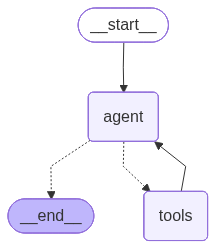

In [9]:
# display graph
from IPython.display import display, Image
display(Image(compiled_ocr_agent_graph.get_graph().draw_mermaid_png()))

In [10]:
response = compiled_ocr_agent_graph.invoke({'messages': HumanMessage(content='what is my candidate number as seen in IELTS_2025.jpg')})

In [11]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my candidate number as seen in IELTS_2025.jpg
================================== Ai Message ==================================
Tool Calls:
  read_image_with_ocr (0de95ffc-fc9a-4055-b64c-3c9029f78747)
 Call ID: 0de95ffc-fc9a-4055-b64c-3c9029f78747
  Args:
    image_file: IELTS_2025.jpg
================================= Tool Message =================================
Name: read_image_with_ocr

3
;

IELTS

Test Report Form GENERAL TRAINING

NOTE. Admission to under ;
‘graduate and post graduate courses should-be based on the ACADEMIC Readin iti
x re - g and. Writing Modules.
BAC TRAINING Reading and Writing Modules are not designed to test the full range of language skills required for academic purposes.
is recommended that the candidate's language ability as indicated in this Test Report Form be re-assessed after two years from the date of the test.

Centre Number ~ 34400 Date 08/FEB/2025 | Candidate

In [12]:
new_response = compiled_ocr_agent_graph.invoke({'messages': HumanMessage(content='what is my last name as seen in IELTS_2025.jpg')})

In [14]:
for m in new_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my last name as seen in IELTS_2025.jpg
================================== Ai Message ==================================
Tool Calls:
  read_image_with_ocr (47ec4170-f33c-444c-8359-7583acee473d)
 Call ID: 47ec4170-f33c-444c-8359-7583acee473d
  Args:
    image_file: IELTS_2025.jpg
================================= Tool Message =================================
Name: read_image_with_ocr

3
;

IELTS

Test Report Form GENERAL TRAINING

NOTE. Admission to under ;
‘graduate and post graduate courses should-be based on the ACADEMIC Readin iti
x re - g and. Writing Modules.
BAC TRAINING Reading and Writing Modules are not designed to test the full range of language skills required for academic purposes.
is recommended that the candidate's language ability as indicated in this Test Report Form be re-assessed after two years from the date of the test.

Centre Number ~ 34400 Date 08/FEB/2025 | Candidate Number

from the above, we can see that the basic agent using pytesseract ocr wasn't good enough

## Phase 2:: Explore processing with PaddleOCR
### Objectives:
    - Use PaddleOCR for text detection and text recognition
    - Use PaddleOCR for layout detection to identify regions of interest
    - building an agent equipped with PaddleOCR tool

    * Limitations:
    limitations on charts and multi-column layouts.

    PaddleOCR loads two models when initialized:
    - _DET: Text detection model (locates text regions)
    - _REC: Text recognition model (reads characters)

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from paddleocr import PaddleOCR

In [20]:
# initialize paddleOCR
ocr = PaddleOCR(lang='en')

/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/agent_env/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/Users/chibuikeiwuchukwu/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
[2026-03-29 19:27:34,376] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-LCNet_x1_0_doc_ori/revision/main "HTTP/1.1 200 OK"
Fetching 6 files:   0%|                                                                                        | 0/6 [00:00<?, ?it/s][2026-03-29 19:27:34,650] [    INFO] _client.py:1025 - HTTP Request: HEAD https

In [ ]:
# load the receipt file
image_path =  './IELTS_2025.jpg'
result =  ocr.predict(image_path)
result